<a href="https://colab.research.google.com/github/thethien8a/Sentiment-Analysis-Vietnamese/blob/m%E1%BA%A1nh/phoBert.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [61]:
# !pip install torch torchvision torchaudio
import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# print(torch.__version__)

In [5]:
# Tên mô hình
model_name = "wonrax/phobert-base-vietnamese-sentiment"

# Load tokenizer & model
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/17.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/999 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

In [64]:
# ---- ĐỌC DATA -----
raw_url = 'https://github.com/thethien8a/Sentiment-Analysis-Vietnamese/raw/main/comment_data/Tram_dung_chan_Jack_shuffled.xlsx'
df = pd.read_excel(raw_url)
df = df[['textDisplay', 'label']]
df.head()

,textDisplay,label
0,Đừng dối lòng phủ nhận tài năng của Jack. Nhìn...,2.0
1,mình là tài xế chạy grab gần 8 năm chưa bao gi...,2.0
2,Sky qua ủng hộ Jack \nChúc dự án này thành côn...,2.0
3,"Không uổn công tui cày từ 5 giờ sáng tới giờ, ...",2.0
4,Đa số nghệ sĩ trong showbiz hiện giờ á toàn qu...,2.0


## TIỀN XỬ LÝ

In [ ]:
# Thử với 150 comment 0<POS<2000; 2220<NEU<3000; 3300<NEG)
df_comment = pd.concat([
    df.iloc[1000:1050],
    df.iloc[2220:2270],
    df.iloc[3300:3350]
]).reset_index(drop=True)

# Thay nhãn
df_comment['label'] = df_comment['label'].replace({
    0.0: 'NEG',
    1.0: 'NEU',
    2.0: 'POS'
})
# Shuffle
df_comment = df_comment.sample(frac=1, random_state = 42).reset_index(drop=True)
df_comment.head(10)

In [ ]:
comment_list = df_comment['textDisplay'].fillna('').tolist()
comment_list[:5]

In [ ]:
# Tạo pipeline cho sentiment analysis
sentiment_pipeline = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)
results = sentiment_pipeline(comment_list)

# --- THÊM KẾT QUẢ VÀO DATAFRAME VÀ LƯU LẠI ---
labels = [result['label'] for result in results]
scores = [result['score'] for result in results]
results[:5]

# Tạo các cột mới trong DataFrame để lưu kết quả
df_comment['sentiment_label'] = labels
df_comment['sentiment_score'] = scores

In [60]:
df_comment.iloc[10:25, 2:]

,textDisplay,likeCount,publishedAt,totalReplyCount,label,sentiment_label,sentiment_score
10,Đạo nhac bá dơ,2,2025-06-09T09:54:42Z,7,NEG,NEG,0.986486
11,Nhà vua đã trở lại!,1,2025-06-07T10:43:37Z,0,POS,POS,0.970874
12,lại hit,128,2025-06-04T13:52:58Z,0,POS,POS,0.889542
13,Hành trình mới mở ra,2,2025-06-05T04:05:49Z,0,POS,POS,0.763357
14,Mv đơn giản nhưng vẫn thịnh hành. Chỉ có thể l...,5,2025-06-05T14:21:56Z,0,POS,NEU,0.685826
15,nhạc hay thì nghe . Nhưng nhân phẩm như *** th...,1,2025-06-09T03:16:49Z,7,NEU,POS,0.990888
16,kể mà ghi nhạc hoa lời việt thì hoàn hảo cmnr ...,0,2025-06-06T10:40:43Z,7,NEG,POS,0.991926
17,Giống bài nơi giấc mộng tan vỡ,0,2025-06-06T11:48:08Z,6,NEU,POS,0.901239
18,Ê ê ê nha a Jack e hay nghe nhạc Trung nghe ph...,0,2025-06-12T05:28:29Z,7,NEU,POS,0.942756
19,Đọc cm của 1 đống fan cảm phục mới chả cảm tạ....,0,2025-06-06T11:57:11Z,7,NEG,NEG,0.869603


## ĐÁNH GIÁ KẾT QUẢ

ĐÁNH GIÁ HIỆU NĂNG MÔ HÌNH
Accuracy (Độ chính xác tổng thể): 50.00%

Classification Report:

              precision    recall  f1-score   support

         NEG       0.53      0.52      0.53        50
         NEU       0.50      0.36      0.42        50
         POS       0.48      0.62      0.54        50

    accuracy                           0.50       150
   macro avg       0.50      0.50      0.49       150
weighted avg       0.50      0.50      0.49       150


Confusion Matrix:


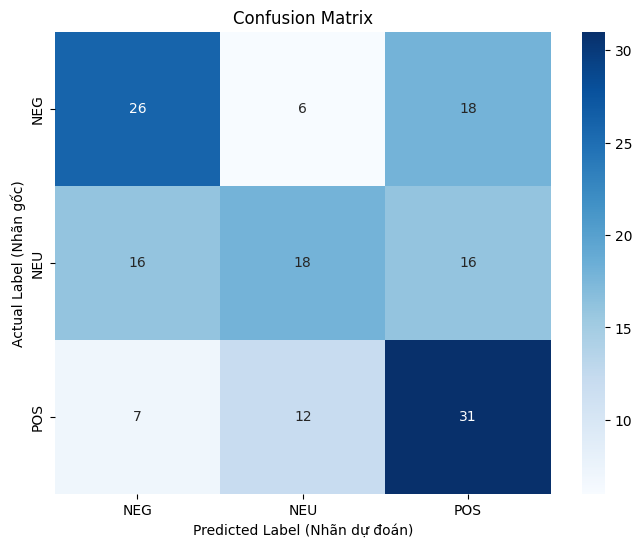

In [62]:
y_true = df_comment['label']
y_pred = df_comment['sentiment_label']

# Xác định tất cả các nhãn có thể có để đảm bảo thứ tự nhất quán
class_names = ['NEG', 'NEU', 'POS']

# --- BƯỚC 2: TÍNH TOÁN VÀ IN CÁC CHỈ SỐ ---
print("ĐÁNH GIÁ HIỆU NĂNG MÔ HÌNH\n" + "="*30)

# 2.1. Độ chính xác tổng thể (Accuracy)
accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy (Độ chính xác tổng thể): {accuracy:.2%}\n")

# 2.2. Báo cáo phân loại chi tiết (Classification Report)
print("Classification Report:\n")
# `labels=class_names` để đảm bảo báo cáo hiển thị tất cả các lớp
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)


# --- BƯỚC 3: VẼ MA TRẬN NHẦM LẪN (CONFUSION MATRIX) ---
print("\nConfusion Matrix:")
cm = confusion_matrix(y_true, y_pred, labels=class_names)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix')
plt.ylabel('Actual Label (Nhãn gốc)')
plt.xlabel('Predicted Label (Nhãn dự đoán)')
plt.show()

In [63]:
# --- BƯỚC 4 (TÙY CHỌN): XEM LẠI CÁC TRƯỜNG HỢP DỰ ĐOÁN SAI ---
print("\nCÁC TRƯỜNG HỢP DỰ ĐOÁN SAI:\n" + "="*30)
misclassified = df_comment[df_comment['label'] != df_comment['sentiment_label']]
print(misclassified[['textDisplay', 'label', 'sentiment_label']])


CÁC TRƯỜNG HỢP DỰ ĐOÁN SAI:
                                           textDisplay label sentiment_label
0    Hôm trước có Đ bảo cô ấy bị dí , ngồi trong gó...   NEU             NEG
1                           cuộc đời đi vào bài nhạc r   POS             NEU
3    Nết đóm vậy biểu sao người ta ko ghét. T vốn k...   NEU             NEG
4    ko p tui chê hay có ý gì đâu vì tôi vẫn nghe n...   NEU             POS
5    Vào đây nghe nhạc! Ko quan tâm ngoài kia bão t...   POS             NEU
..                                                 ...   ...             ...
139       梦散之地 | Nơi Giấc Mộng Tan Vỡ - Ele Yan  :))))   NEG             POS
141                             Vụ đạo nhái sao r mng?   NEU             NEG
142  😢Ở bên Facebook có nghe 2 bài hát so sánh với ...   NEG             NEU
144                                             Đã quá   POS             NEG
145                     Vl giống bài take my heart thế   NEU             POS

[75 rows x 3 columns]
